In [1]:
%reload_ext autoreload
%autoreload 2

In [5]:
from waymo_agent import *

In [6]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [7]:
from waymo_agent.osmnx import *
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int
from waymo_agent.osmnx.post_process_enrichment import *

#### Load Sparse Graph

In [8]:
config = EnvConfig()
config.map_name

'manhattan-sparse-774-nodes-enriched.graphml'

In [9]:
G = ox.load_graphml(filepath=MAP_DIR / config.map_name)
post_load(G)

In [10]:
inspect_graph(G)

Graph has 774 nodes and 1613 edges.
Sample node -sample_node_id=42437962- attributes: {'y': 40.717351, 'x': -73.9911718, 'highway': 'traffic_signals', 'street_count': 4, 'lambda': '0.0073382542032971836', 'x_centered': '-929.7626438797452', 'y_centered': '-4166.123406028375', 'x_norm': '-0.1298308192360415', 'y_norm': '-0.5817519324997423'}

Sample edge attributes: {'osmid': 458166895, 'highway': 'secondary', 'lanes': '3', 'maxspeed': 64.74938089, 'name': 'East 36th Street', 'oneway': True, 'reversed': False, 'length': 154.62593994025465, 'geometry': <LINESTRING (-73.979 40.748, -73.979 40.748, -73.978 40.747, -73.977 40.747,...>, 'unit': 'kph', 'travel_time_min': '0.23059282429853925'}


In [11]:
DEFAULT_OX_PLOT_NOTEBOOK

{'node_size': 5,
 'node_color': 'white',
 'node_alpha': 0.5,
 'figsize': (10, 10),
 'bgcolor': 'black',
 'show': True}

In [12]:
env = RideShareEnv()
G = env.graph

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [13]:
obs, info = env.reset()

In [14]:
from waymo_agent.osmnx.shortest_path import calculate_longest_path


maxlen, path = calculate_longest_path(G, weight="length")
maxlen, len(path)

(18244.60388871296, 59)

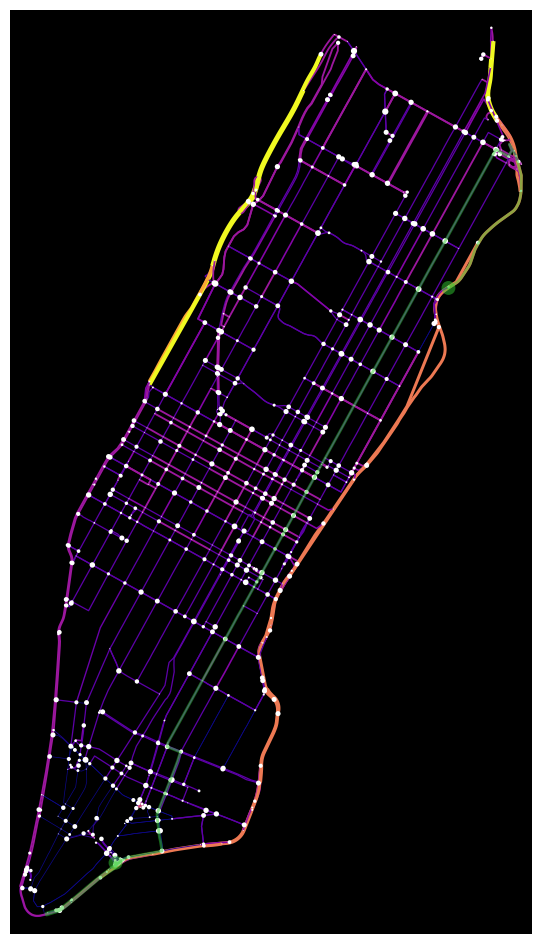

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [15]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(12, 12),
    show=False,
    bgcolor="black",
)
ox.plot_graph_route(G, path, route_color="limegreen", route_linewidth=2.0, ax=ax, orig_dest_node_size=100)

In [16]:
from waymo_agent.data_classes.dataclasses import RequestStatusEnum


RequestStatusEnum

<enum 'RequestStatusEnum'>

In [17]:
plot_request_types = set([RequestStatusEnum.AWAITING_PRICE, RequestStatusEnum.ACCEPTED, RequestStatusEnum.ASSIGNED])